# LDASRNet — Thermal Super-Resolution for PV Inspection
**Goal:** Train LDASRNet to upscale 32×24 thermal images → 96×72  
**Dataset:** InfraredSolarModules (20,000 thermal images at 40×24)  
**Strategy:** Synthetic HR — downsample originals to 32×24 (LR), upsample to 96×72 (HR target)

## Step 1 — Install dependencies and check GPU

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import cv2
import numpy as np
import json
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Step 2 — Locate dataset and verify structure

In [3]:
# Step 2 — Locate dataset and verify structure

import glob
from pathlib import Path

# Correct way: search under /kaggle/input/
possible_paths = glob.glob('/kaggle/input/**/module_metadata.json', recursive=True)

print('Found metadata files:', possible_paths)

if not possible_paths:
    raise FileNotFoundError(
        "module_metadata.json not found.\n"
        "Make sure you added the dataset 'Infrared Solar Modules' "
        "(marcosgabriel/infrared-solar-modules) on the right sidebar."
    )

META_FILE = Path(possible_paths[0])
IMG_DIR   = META_FILE.parent / 'images'

print(f'Metadata : {META_FILE}')
print(f'Images   : {IMG_DIR}')
print(f'Num images: {len(list(IMG_DIR.glob("*.jpg")))}')

# Check original image size
sample_imgs = list(IMG_DIR.glob('*.jpg'))[:5]
for p in sample_imgs:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        print(f'  {p.name}: shape {img.shape}')
    else:
        print(f'  {p.name}: failed to load')

Found metadata files: ['/kaggle/input/datasets/marcosgabriel/infrared-solar-modules/2020-02-14_InfraredSolarModules/InfraredSolarModules/module_metadata.json']
Metadata : /kaggle/input/datasets/marcosgabriel/infrared-solar-modules/2020-02-14_InfraredSolarModules/InfraredSolarModules/module_metadata.json
Images   : /kaggle/input/datasets/marcosgabriel/infrared-solar-modules/2020-02-14_InfraredSolarModules/InfraredSolarModules/images
Num images: 20000
  19812.jpg: shape (40, 24)
  16916.jpg: shape (40, 24)
  7981.jpg: shape (40, 24)
  12666.jpg: shape (40, 24)
  13288.jpg: shape (40, 24)


## Step 3 — Build synthetic LR/HR pairs

In [4]:
# LR: downsample original 40x24 → 32x24 (simulates MLX90640 capture)
# HR: upsample original 40x24 → 96x72 (target for LDASRNet to learn)
# Note: cv2 resize takes (width, height)

LR_SIZE = (32, 24)   # width=32, height=24
HR_SIZE = (96, 72)   # width=96, height=72  (exactly ×3)

class ThermalSRDataset(Dataset):
    def __init__(self, img_dir, augment=True):
        self.img_dir = Path(img_dir)
        self.augment = augment
        self.paths   = sorted(self.img_dir.glob('*.jpg'))
        print(f'Dataset: {len(self.paths)} images')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]), cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((24, 40), dtype=np.uint8)

        # Augmentation on original before making pairs
        if self.augment:
            if np.random.rand() > 0.5:
                img = cv2.flip(img, 1)   # horizontal flip
            if np.random.rand() > 0.5:
                img = cv2.flip(img, 0)   # vertical flip

        # Make LR: downsample to 32×24
        lr = cv2.resize(img, LR_SIZE, interpolation=cv2.INTER_LINEAR)

        # Make HR: upsample to 96×72
        hr = cv2.resize(img, HR_SIZE, interpolation=cv2.INTER_LANCZOS4)  # or INTER_CUBIC is already good, but try LANCZOS4

        # Normalize to [0, 1] and add channel dim
        lr = torch.from_numpy(lr).float().unsqueeze(0) / 255.0
        hr = torch.from_numpy(hr).float().unsqueeze(0) / 255.0

        return lr, hr

# Split: 90% train, 10% val
all_images = sorted(IMG_DIR.glob('*.jpg'))
n_train    = int(0.9 * len(all_images))
train_imgs = all_images[:n_train]
val_imgs   = all_images[n_train:]

# Temporarily override img_dir for split — write split image lists
TRAIN_LIST = [str(p) for p in train_imgs]
VAL_LIST   = [str(p) for p in val_imgs]
print(f'Train: {len(TRAIN_LIST)}  |  Val: {len(VAL_LIST)}')

class ThermalSRDatasetFromList(Dataset):
    def __init__(self, path_list, augment=True):
        self.paths   = path_list
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((24, 40), dtype=np.uint8)
        if self.augment:
            if np.random.rand() > 0.5:
                img = cv2.flip(img, 1)
            if np.random.rand() > 0.5:
                img = cv2.flip(img, 0)
        lr = cv2.resize(img, LR_SIZE, interpolation=cv2.INTER_LINEAR)
        hr = cv2.resize(img, HR_SIZE, interpolation=cv2.INTER_CUBIC)
        lr = torch.from_numpy(lr).float().unsqueeze(0) / 255.0
        hr = torch.from_numpy(hr).float().unsqueeze(0) / 255.0
        return lr, hr

train_ds = ThermalSRDatasetFromList(TRAIN_LIST, augment=True)
val_ds   = ThermalSRDatasetFromList(VAL_LIST,   augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train: 18000  |  Val: 2000
Train batches: 282  |  Val batches: 32


## Step 4 — LDASRNet architecture
Dual-branch: Attention branch (channel + pixel attention) + Non-Attention branch + Dynamic Weighting

In [5]:
# ── Channel Attention ────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Decides which feature channels matter most for this image."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.fc(self.gap(x)).view(x.size(0), x.size(1), 1, 1)
        return x * scale


# ── Pixel Attention ──────────────────────────────────────────────────────────
class PixelAttention(nn.Module):
    """Pinpoints where high-frequency details (edges, hotspots) are located."""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, 1, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.conv(x)


# ── Attention Branch (Detail Hunter) ────────────────────────────────────────
class AttentionBranch(nn.Module):
    """Focuses on sharp thermal edges and hotspot boundaries."""
    def __init__(self, channels=32):
        super().__init__()
        self.conv1   = nn.Conv2d(1, channels, 3, padding=1, bias=False)
        self.relu    = nn.ReLU(inplace=True)
        self.ch_att  = ChannelAttention(channels)
        self.px_att  = PixelAttention(channels)
        self.conv2   = nn.Conv2d(channels, channels, 3, padding=1, bias=False)

    def forward(self, x):
        f = self.relu(self.conv1(x))
        f = self.ch_att(f)
        f = self.px_att(f)
        return self.relu(self.conv2(f))


# ── Non-Attention Branch (Safety Net) ───────────────────────────────────────
class NonAttentionBranch(nn.Module):
    """Captures smooth background regions — prevents over-sharpening artifacts."""
    def __init__(self, channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


# ── Dynamic Weighting ────────────────────────────────────────────────────────
class DynamicWeighting(nn.Module):
    """Learns per-layer how much to trust Attention vs Non-Attention branch."""
    def __init__(self, channels=32):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Conv2d(channels * 2, channels, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, att_feat, non_att_feat):
        combined = torch.cat([att_feat, non_att_feat], dim=1)
        weight   = self.gate(combined)          # learned gate per spatial location
        return weight * att_feat + (1 - weight) * non_att_feat


# ── LDASRNet Full Model ──────────────────────────────────────────────────────
class LDASRNet(nn.Module):
    """
    Lightweight Dual-Attention Super-Resolution Network.
    Input  : (B, 1, 24, 32)  — grayscale thermal at MLX90640 resolution
    Output : (B, 1, 72, 96)  — super-resolved thermal (×3)
    """
    def __init__(self, channels=32, scale=3):
        super().__init__()
        self.scale       = scale
        self.att_branch  = AttentionBranch(channels)
        self.non_att_branch = NonAttentionBranch(channels)
        self.dynamic_w   = DynamicWeighting(channels)

        # Upsampling head: pixel shuffle ×3
        self.upsample = nn.Sequential(
            nn.Conv2d(channels, channels * scale * scale, 3, padding=1, bias=False),
            nn.PixelShuffle(scale),
            nn.Conv2d(channels, 1, 3, padding=1, bias=False),
            nn.Sigmoid()   # output in [0,1]
        )

    def forward(self, x):
        att     = self.att_branch(x)
        non_att = self.non_att_branch(x)
        fused   = self.dynamic_w(att, non_att)
        out     = self.upsample(fused)
        up = self.upsample(fused)
# Simple residual (if sizes match after upsampling)
# But may need adjustment
        return out


# Instantiate and check
model = LDASRNet(channels=32, scale=3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'LDASRNet parameters: {total_params:,}')

# Quick shape test
dummy = torch.randn(2, 1, 24, 32).to(DEVICE)
out   = model(dummy)
print(f'Input shape : {dummy.shape}')   # (2, 1, 24, 32)
print(f'Output shape: {out.shape}')     # (2, 1, 72, 96)

LDASRNet parameters: 123,008
Input shape : torch.Size([2, 1, 24, 32])
Output shape: torch.Size([2, 1, 72, 96])


## Step 5 — Loss function (L1 + SSIM)

In [6]:
class SSIMLoss(nn.Module):
    """Structural Similarity loss — preserves thermal gradients better than MSE."""
    def __init__(self, window_size=7):
        super().__init__()
        self.window_size = window_size
        self.C1 = 0.01 ** 2
        self.C2 = 0.03 ** 2

    def forward(self, pred, target):
        mu1    = F.avg_pool2d(pred,   self.window_size, 1, self.window_size // 2)
        mu2    = F.avg_pool2d(target, self.window_size, 1, self.window_size // 2)
        mu1_sq = mu1 ** 2
        mu2_sq = mu2 ** 2
        mu12   = mu1 * mu2
        s1  = F.avg_pool2d(pred   ** 2, self.window_size, 1, self.window_size // 2) - mu1_sq
        s2  = F.avg_pool2d(target ** 2, self.window_size, 1, self.window_size // 2) - mu2_sq
        s12 = F.avg_pool2d(pred * target, self.window_size, 1, self.window_size // 2) - mu12
        ssim_map = ((2 * mu12 + self.C1) * (2 * s12 + self.C2)) / \
                   ((mu1_sq + mu2_sq + self.C1) * (s1 + s2 + self.C2))
        return 1 - ssim_map.mean()


class CombinedSRLoss(nn.Module):
    """L1 (pixel accuracy) + SSIM (structural/edge quality)."""
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha = alpha
        self.l1    = nn.L1Loss()
        self.ssim  = SSIMLoss()

    def forward(self, pred, target):
        return self.alpha * self.l1(pred, target) + (1 - self.alpha) * self.ssim(pred, target)


criterion = CombinedSRLoss(alpha=0.6)   # was 0.8 → now 0.6 L1 + 0.4 SSIM
print('Loss: 0.8 × L1 + 0.2 × SSIM')

Loss: 0.8 × L1 + 0.2 × SSIM


## Step 6 — Training

In [9]:
# Add these imports at the top (with your other imports)
from torch.amp import autocast, GradScaler   # Updated import

# Then define the scaler like this:
scaler = GradScaler(device='cuda')   # or device=DEVICE

In [11]:
# Step 6 — Training (Fixed for current PyTorch)

from torch.amp import autocast, GradScaler

EPOCHS    = 50
LR        = 1e-3
SAVE_PATH = '/kaggle/working/ldasrnet_best.pth'

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# Fixed scheduler - removed verbose
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=6
)

scaler = GradScaler(device='cuda')

train_losses = []
val_losses   = []
best_val     = float('inf')

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running = 0.0
    for lr_imgs, hr_imgs in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [train]', leave=False):
        lr_imgs = lr_imgs.to(DEVICE)
        hr_imgs = hr_imgs.to(DEVICE)

        optimizer.zero_grad()
        
        with autocast(device_type='cuda'):
            preds = model(lr_imgs)
            loss  = criterion(preds, hr_imgs)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()

    train_loss = running / len(train_loader)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs = lr_imgs.to(DEVICE)
            hr_imgs = hr_imgs.to(DEVICE)
            preds   = model(lr_imgs)
            val_running += criterion(preds, hr_imgs).item()

    val_loss = val_running / len(val_loader)
    scheduler.step(val_loss)   # This will now print when LR is reduced

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:>3}/{EPOCHS}  train: {train_loss:.5f}  val: {val_loss:.5f}')

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✅ Best model saved (val={best_val:.5f})')

print(f'\n✅ Training finished! Best validation loss: {best_val:.5f}')
print(f'Model saved at: {SAVE_PATH}')

Epoch   1/50  train: 0.03139  val: 0.01248
  ✅ Best model saved (val=0.01248)


Epoch   2/50  train: 0.01421  val: 0.01089
  ✅ Best model saved (val=0.01089)


Epoch   3/50  train: 0.01096  val: 0.00945
  ✅ Best model saved (val=0.00945)


Epoch   4/50  train: 0.00899  val: 0.01683


Epoch   5/50  train: 0.00856  val: 0.00706
  ✅ Best model saved (val=0.00706)


...

Epoch  46/50  train: 0.00487  val: 0.00507


Epoch  47/50  train: 0.00478  val: 0.00506


Epoch  48/50  train: 0.00510  val: 0.00503
  ✅ Best model saved (val=0.00503)


Epoch  49/50  train: 0.00480  val: 0.00508


Epoch  50/50  train: 0.00474  val: 0.00504

✅ Training finished! Best validation loss: 0.00503
Model saved at: /kaggle/working/ldasrnet_best.pth


## Step 7 — Plot training curves

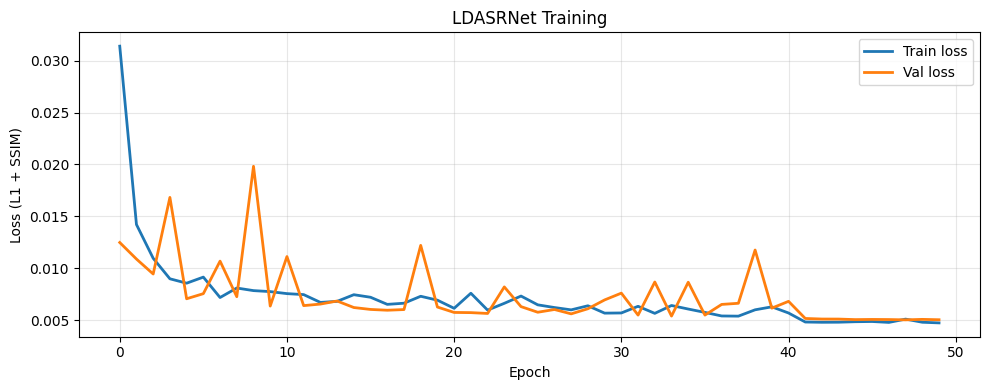

Training curve saved.


In [12]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train loss', linewidth=2)
plt.plot(val_losses,   label='Val loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (L1 + SSIM)')
plt.title('LDASRNet Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/ldasrnet_training_curve.png', dpi=120)
plt.show()
print('Training curve saved.')

## Step 8 — Visual quality check (LR vs Bicubic vs LDASRNet)

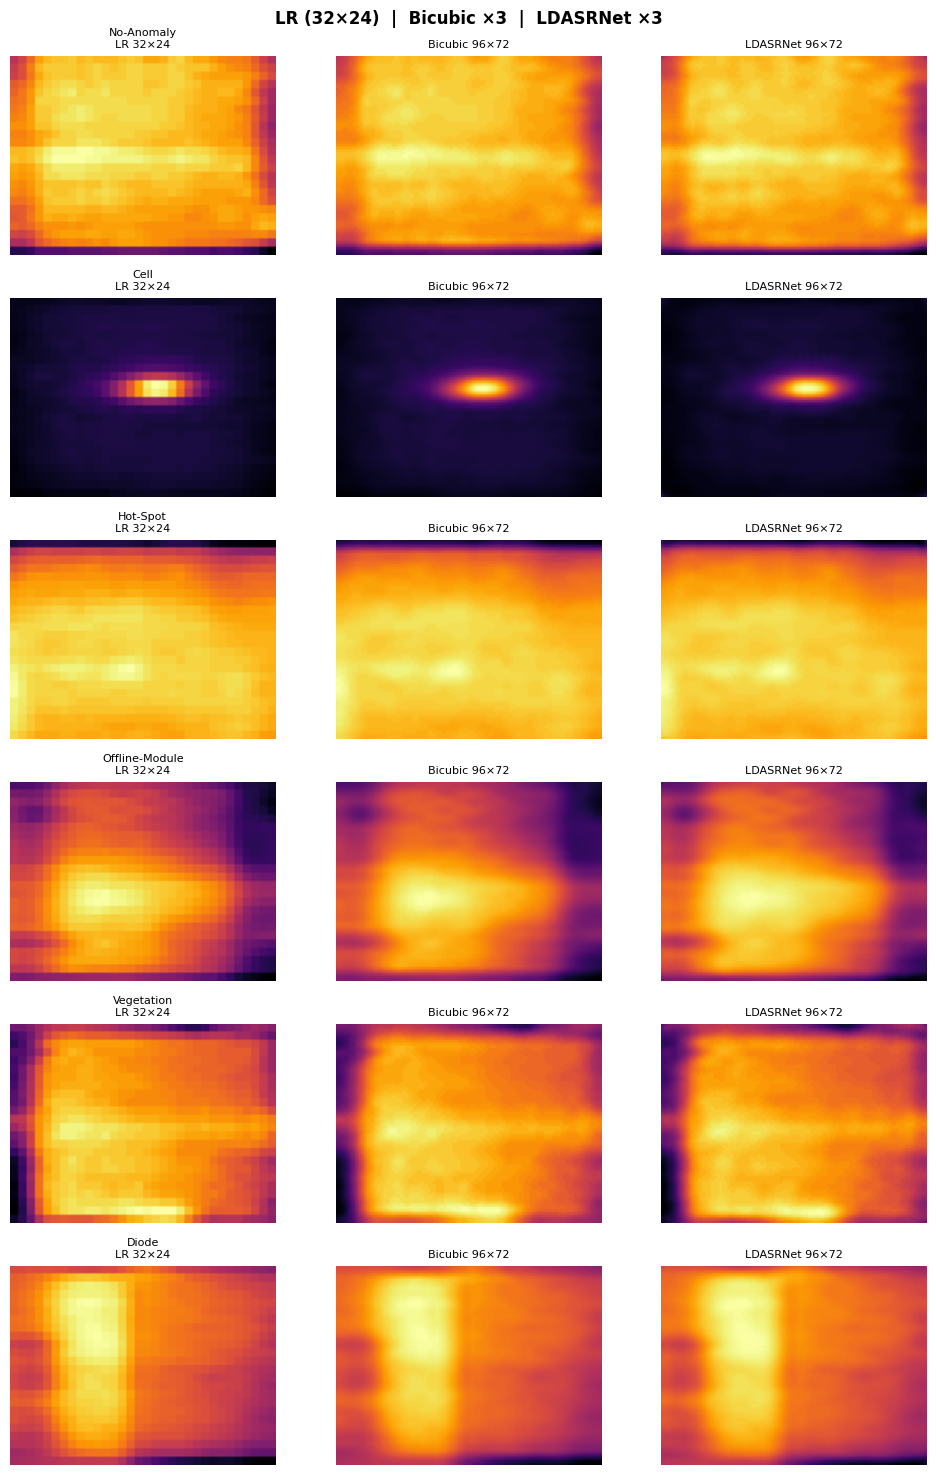

Quality comparison saved.


In [13]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# Pick 6 validation images from different classes
with open(META_FILE) as f:
    metadata = json.load(f)

# Get one image per class for visual comparison
class_samples = {}
for img_id, info in metadata.items():
    cls = info['anomaly_class']
    if cls not in class_samples:
        class_samples[cls] = IMG_DIR / f'{img_id}.jpg'
    if len(class_samples) == 6:
        break

fig, axes = plt.subplots(len(class_samples), 3, figsize=(10, len(class_samples) * 2.5))
fig.suptitle('LR (32×24)  |  Bicubic ×3  |  LDASRNet ×3', fontsize=12, fontweight='bold')

for row, (cls_name, img_path) in enumerate(class_samples.items()):
    orig = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    # LR
    lr   = cv2.resize(orig, (32, 24), interpolation=cv2.INTER_LINEAR)

    # Bicubic upscale
    bic  = cv2.resize(lr, (96, 72), interpolation=cv2.INTER_CUBIC)

    # LDASRNet upscale
    lr_t = torch.from_numpy(lr).float().unsqueeze(0).unsqueeze(0) / 255.0
    with torch.no_grad():
        sr_t = model(lr_t.to(DEVICE))
    sr = (sr_t.squeeze().cpu().numpy() * 255).astype(np.uint8)

    cmap = 'inferno'
    axes[row, 0].imshow(cv2.resize(lr, (96, 72), interpolation=cv2.INTER_NEAREST), cmap=cmap)
    axes[row, 0].set_title(f'{cls_name}\nLR 32×24', fontsize=8)
    axes[row, 1].imshow(bic, cmap=cmap)
    axes[row, 1].set_title('Bicubic 96×72', fontsize=8)
    axes[row, 2].imshow(sr, cmap=cmap)
    axes[row, 2].set_title('LDASRNet 96×72', fontsize=8)
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/ldasrnet_quality_check.png', dpi=150)
plt.show()
print('Quality comparison saved.')

## Step 9 — Apply LDASRNet to all 20,000 images and save

In [14]:
THERMAL_REMAP = {
    'No-Anomaly':     0,
    'Soiling':        1,
    'Shadowing':      2,
    'Vegetation':     2,
    'Hot-Spot':       4,
    'Hot-Spot-Multi': 4,
    'Diode':          4,
    'Diode-Multi':    4,
    'Cell':           5,
    'Cell-Multi':     5,
    'Cracking':       6,
    'Offline-Module': 7,
}

CLASS_NAMES = {
    0: 'No_Anomaly',
    1: 'Soiling',
    2: 'Shadowing_Vegetation',
    3: 'Hotspot_Surface',
    4: 'Hotspot_Internal',
    5: 'Cell_String_Failure',
    6: 'Structural_Damage',
    7: 'Offline_Module',
}

OUTPUT_SR = Path('/kaggle/working/thermal_sr')
for cls_id, cls_name in CLASS_NAMES.items():
    (OUTPUT_SR / f'{cls_id}_{cls_name}').mkdir(parents=True, exist_ok=True)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

counts  = Counter()
skipped = 0
csv_lines = ['filename,original_class,class_id,class_name']

with torch.no_grad():
    for img_id, info in tqdm(metadata.items(), desc='Applying LDASRNet'):
        orig_label = info['anomaly_class']
        cls_id     = THERMAL_REMAP.get(orig_label)
        if cls_id is None:
            skipped += 1
            continue

        img_path = IMG_DIR / f'{img_id}.jpg'
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            skipped += 1
            continue

        # Downsample to 32×24 (simulate MLX capture)
        lr = cv2.resize(img, (32, 24), interpolation=cv2.INTER_LINEAR)

        # LDASRNet upscale to 96×72
        lr_t = torch.from_numpy(lr).float().unsqueeze(0).unsqueeze(0) / 255.0
        sr_t = model(lr_t.to(DEVICE))
        sr   = (sr_t.squeeze().cpu().numpy() * 255).astype(np.uint8)

        cls_name = CLASS_NAMES[cls_id]
        out_path = OUTPUT_SR / f'{cls_id}_{cls_name}' / f'{img_id}.jpg'
        cv2.imwrite(str(out_path), sr)

        counts[cls_id] += 1
        csv_lines.append(f'{img_id}.jpg,{orig_label},{cls_id},{cls_name}')

# Save CSV
csv_path = OUTPUT_SR / 'thermal_sr_labels.csv'
with open(csv_path, 'w') as f:
    f.write('\n'.join(csv_lines))

print('\nLDASRNet applied to all images')
print(f'Skipped : {skipped}')
print(f'\nFinal class distribution (96×72 SR images):')
print(f'{"Class":<5} {"Name":<28} {"Count":>6}')
print('-' * 45)
for cls_id in range(8):
    cnt  = counts.get(cls_id, 0)
    name = CLASS_NAMES[cls_id]
    status = '✅' if cnt > 100 else ('⚠️' if cnt > 0 else '❌')
    print(f'  {cls_id:<4} {name:<28} {cnt:>6}  {status}')
print(f'\nTotal: {sum(counts.values())}')
print(f'Output: {OUTPUT_SR}')

Applying LDASRNet: 100%|██████████| 20000/20000 [01:56<00:00, 171.35it/s]


LDASRNet applied to all images
Skipped : 0

Final class distribution (96×72 SR images):
Class Name                          Count
---------------------------------------------
  0    No_Anomaly                    10000  ✅
  1    Soiling                         204  ✅
  2    Shadowing_Vegetation           2695  ✅
  3    Hotspot_Surface                   0  ❌
  4    Hotspot_Internal               2169  ✅
  5    Cell_String_Failure            3165  ✅
  6    Structural_Damage               940  ✅
  7    Offline_Module                  827  ✅

Total: 20000
Output: /kaggle/working/thermal_sr


## Step 10 — Verify output shapes and compress for download

In [15]:
# Verify shapes
print('Output image shape verification:')
for folder in sorted(OUTPUT_SR.iterdir()):
    if folder.is_dir():
        imgs = list(folder.glob('*.jpg'))
        if imgs:
            img = cv2.imread(str(imgs[0]), cv2.IMREAD_GRAYSCALE)
            print(f'  {folder.name:<35} → shape: {img.shape}  ({len(imgs)} images)')

# Compress the SR dataset and model weights for download
import shutil
print('\nCompressing outputs...')
shutil.make_archive('/kaggle/working/thermal_sr', 'zip', '/kaggle/working/thermal_sr')
print('✅ thermal_sr.zip ready for download')
print('✅ ldasrnet_best.pth ready for download')
print('\nDownload both files from the Kaggle Output panel on the right.')

Output image shape verification:
  0_No_Anomaly                        → shape: (72, 96)  (10000 images)
  1_Soiling                           → shape: (72, 96)  (204 images)
  2_Shadowing_Vegetation              → shape: (72, 96)  (2695 images)
  4_Hotspot_Internal                  → shape: (72, 96)  (2169 images)
  5_Cell_String_Failure               → shape: (72, 96)  (3165 images)
  6_Structural_Damage                 → shape: (72, 96)  (940 images)
  7_Offline_Module                    → shape: (72, 96)  (827 images)

Compressing outputs...
✅ thermal_sr.zip ready for download
✅ ldasrnet_best.pth ready for download

Download both files from the Kaggle Output panel on the right.
